In [1]:
import numpy as np
import pandas as pd
import os
import string
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Embedding
from tensorflow.keras.utils import plot_model

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:

print("Downloading dataset...")
path = kagglehub.dataset_download("marufchowdhury/quote-dataset")
print("Path to dataset files:", path)

df = pd.read_csv(os.path.join(path, 'Quote_data.csv'))
print(f"✅ Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")

100%|██████████| 3.91M/3.91M [00:01<00:00, 3.14MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/marufchowdhury/quote-dataset/versions/2
✅ Data loaded: 29355 rows, 4 columns
Columns: ['Quote', 'Author', 'Tags', 'revised_tags']


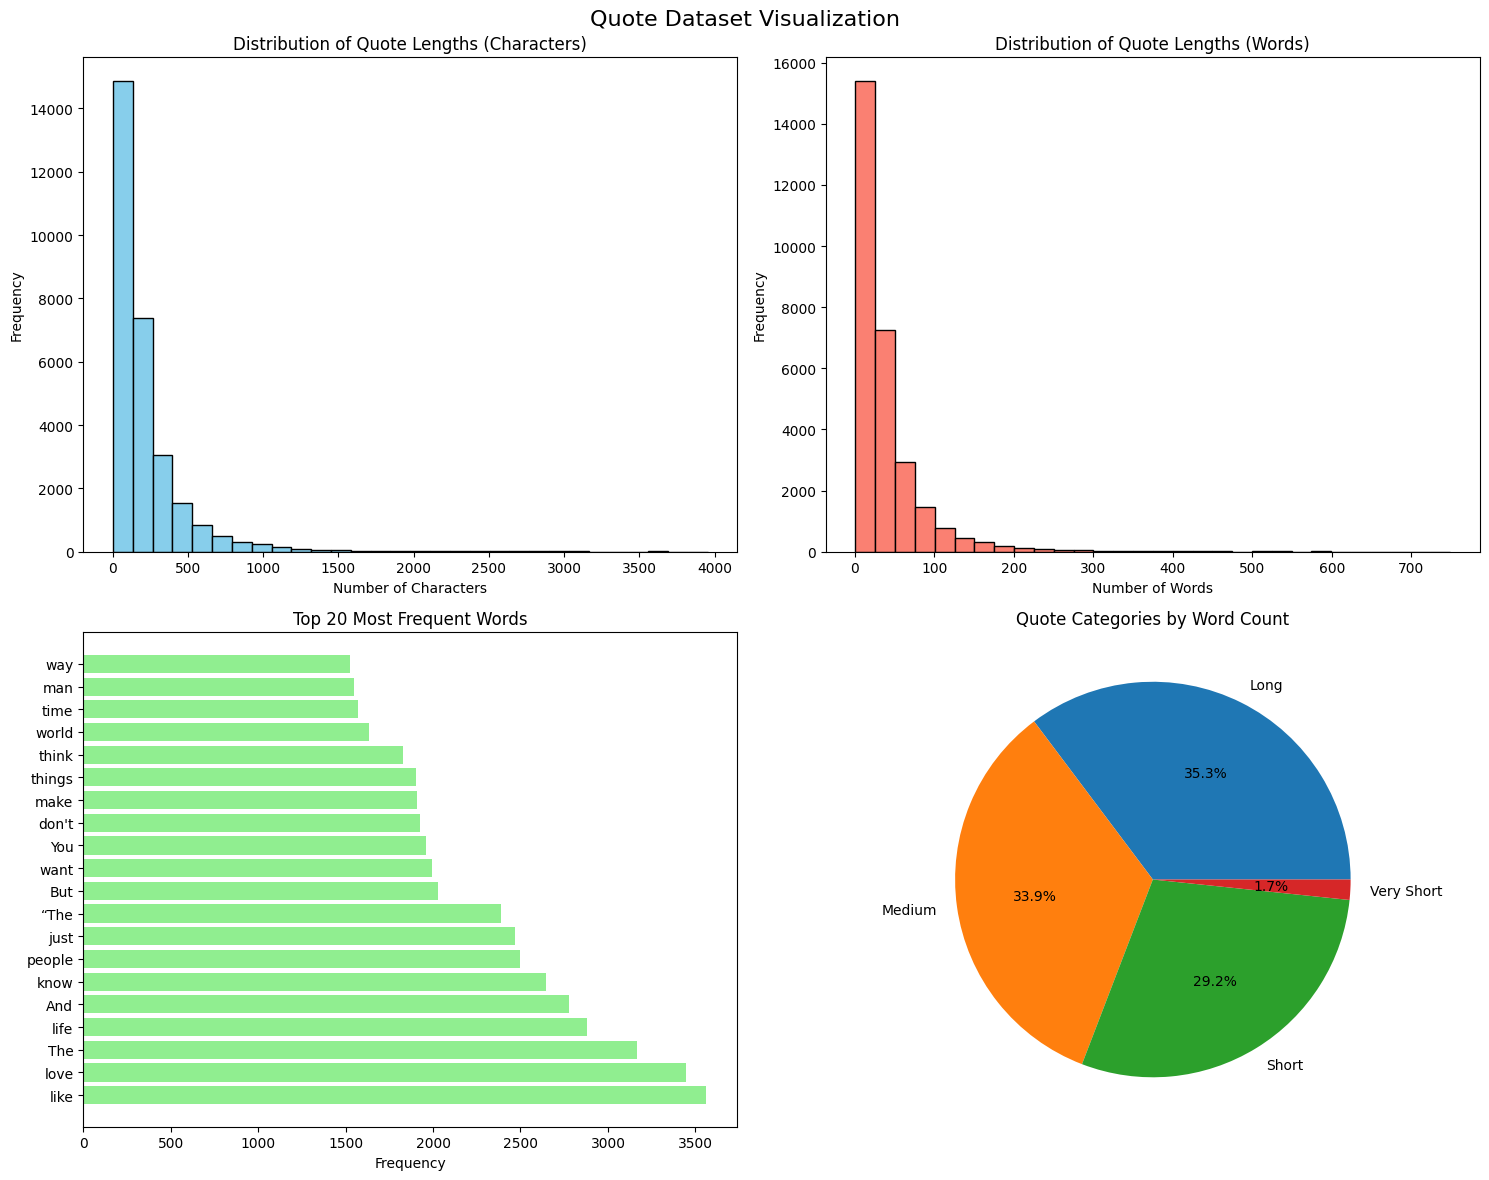

In [3]:


fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Quote Dataset Visualization', fontsize=16)


quote_lengths = df['Quote'].str.len()
axes[0, 0].hist(quote_lengths, bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Quote Lengths (Characters)')
axes[0, 0].set_xlabel('Number of Characters')
axes[0, 0].set_ylabel('Frequency')


quote_words = df['Quote'].str.split().str.len()
axes[0, 1].hist(quote_words, bins=30, color='salmon', edgecolor='black')
axes[0, 1].set_title('Distribution of Quote Lengths (Words)')
axes[0, 1].set_xlabel('Number of Words')
axes[0, 1].set_ylabel('Frequency')

all_text = ' '.join(df['Quote'].astype(str))
words = all_text.split()
word_freq = Counter(words)
stopwords = set(ENGLISH_STOP_WORDS)
filtered_words = {word: freq for word, freq in word_freq.items()
                  if word not in stopwords and len(word) > 2}
top_words = dict(sorted(filtered_words.items(), key=lambda x: x[1], reverse=True)[:20])

axes[1, 0].barh(list(top_words.keys()), list(top_words.values()), color='lightgreen')
axes[1, 0].set_title('Top 20 Most Frequent Words')
axes[1, 0].set_xlabel('Frequency')

df['Category'] = pd.cut(quote_words, bins=[0, 5, 15, 30, 100],
                        labels=['Very Short', 'Short', 'Medium', 'Long'])
category_counts = df['Category'].value_counts()
axes[1, 1].pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%')
axes[1, 1].set_title('Quote Categories by Word Count')

plt.tight_layout()
plt.show()

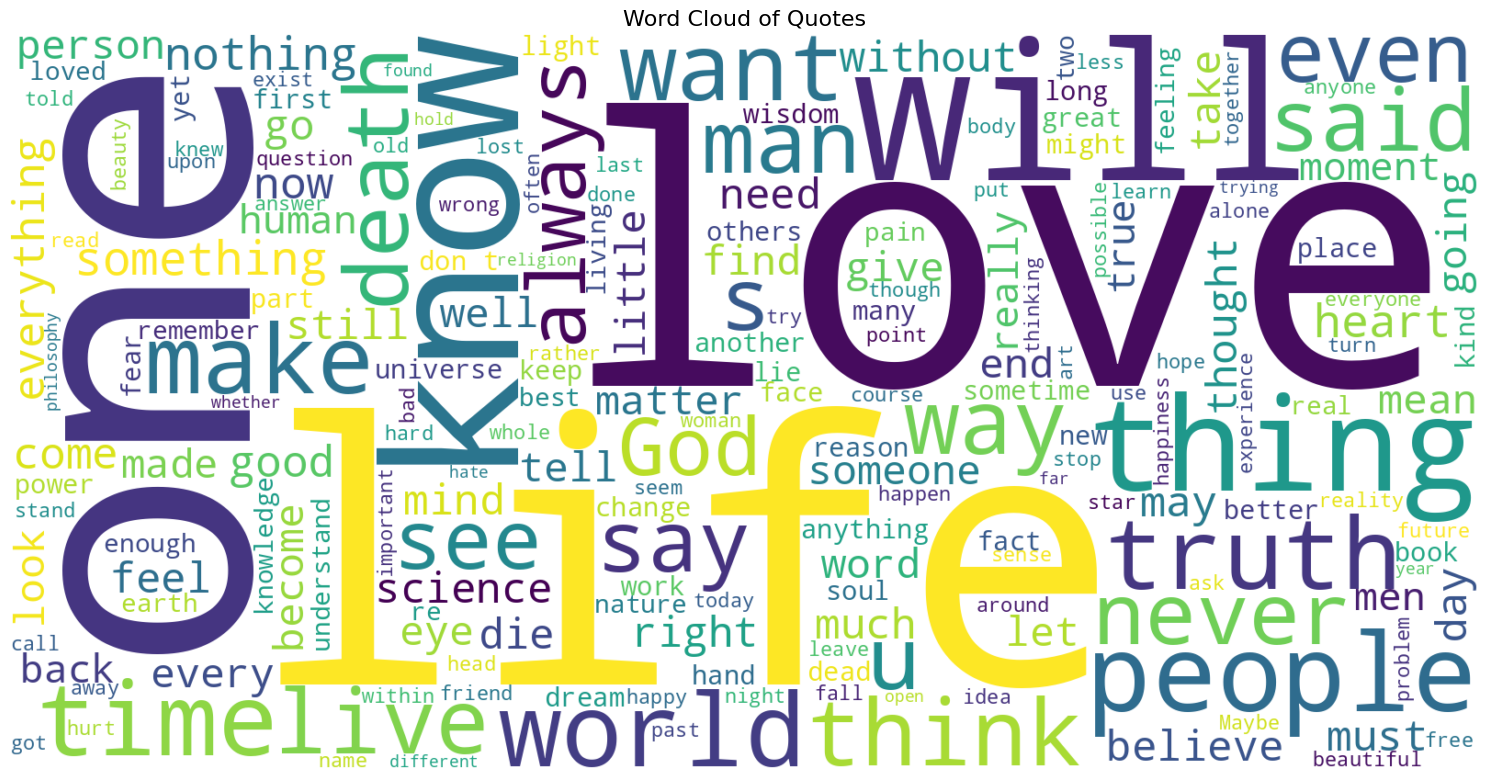

In [4]:

plt.figure(figsize=(15, 8))
wordcloud = WordCloud(width=1600, height=800, background_color='white',
                      max_words=200, contour_width=3, contour_color='steelblue')
wordcloud.generate(all_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Quotes', fontsize=16)
plt.tight_layout()
plt.show()

In [5]:

print("\nCreating model architecture visualization...")

vocab_size = 30000
embedding_dim = 50
rnn_units = 128
max_len = 50

rnn_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    SimpleRNN(units=rnn_units, activation='tanh'),
    Dense(units=vocab_size, activation='softmax')
])

rnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

try:
    plot_model(rnn_model, show_shapes=True, show_layer_names=True,
               dpi=60, to_file='rnn_model_architecture.png')
    print("✅ Model architecture saved as 'rnn_model_architecture.png'")
except Exception as e:
    print(f"Note: Could not save model plot: {e}")
    print("Displaying model summary instead:")
    rnn_model.summary()


Creating model architecture visualization...
Note: Could not save model plot: This model has not yet been built. Build the model first by calling `build()` or by calling the model on a batch of data.
Displaying model summary instead:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

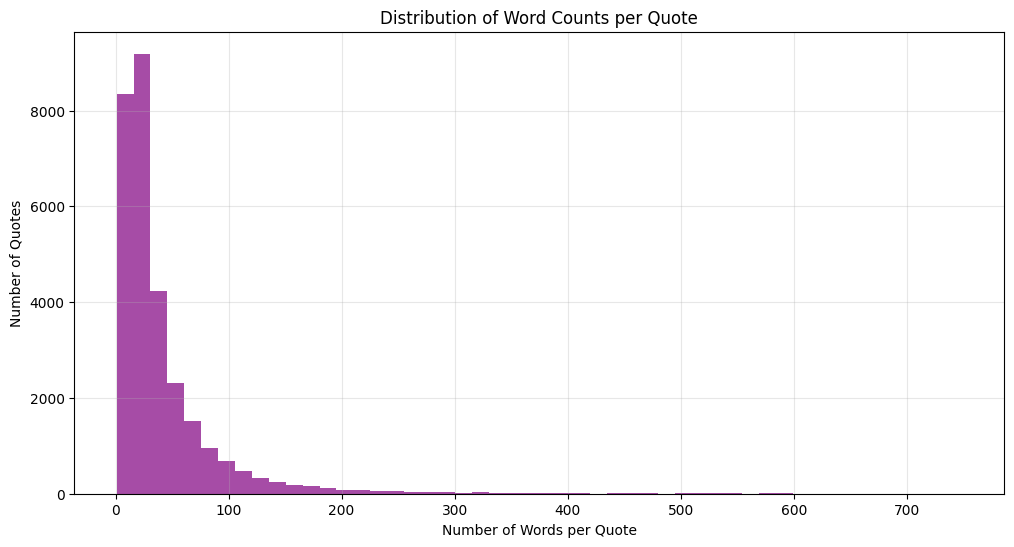

In [6]:

plt.figure(figsize=(12, 6))
word_counts = df['Quote'].str.split().apply(len)
plt.hist(word_counts, bins=50, color='purple', alpha=0.7)
plt.xlabel('Number of Words per Quote')
plt.ylabel('Number of Quotes')
plt.title('Distribution of Word Counts per Quote')
plt.grid(True, alpha=0.3)
plt.show()

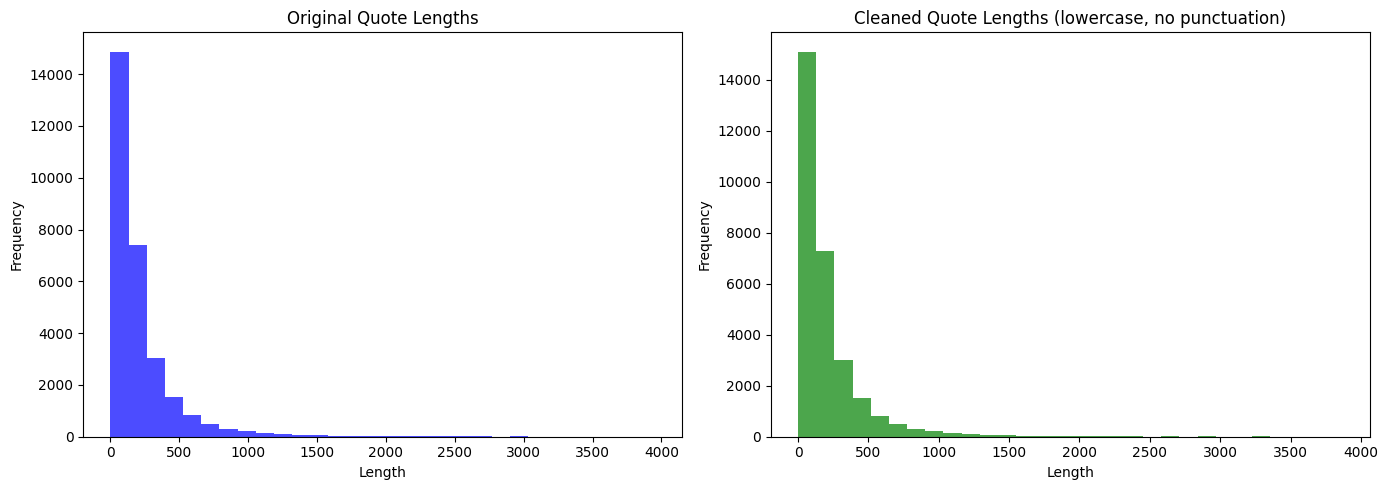

In [7]:

df_original = pd.read_csv(os.path.join(path, 'Quote_data.csv'))
df['Quote_clean'] = df['Quote'].str.lower().str.replace(r'[^\w\s]', '', regex=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_original['Quote'].str.len(), bins=30, alpha=0.7, label='Original', color='blue')
axes[0].set_title('Original Quote Lengths')
axes[0].set_xlabel('Length')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['Quote_clean'].str.len(), bins=30, alpha=0.7, label='Cleaned', color='green')
axes[1].set_title('Cleaned Quote Lengths (lowercase, no punctuation)')
axes[1].set_xlabel('Length')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [8]:

print("\n📊 Sample Quotes (First 10):")
print("="*60)
for i in range(min(10, len(df))):
    quote = df['Quote'][i] if i < len(df) else "N/A"
    word_count = len(str(quote).split())
    char_count = len(str(quote))
    if len(str(quote)) > 60:
        print(f"{i+1}. Quote: {str(quote)[:60]}...")
    else:
        print(f"{i+1}. Quote: {quote}")
    print(f"   Words: {word_count}, Characters: {char_count}")
    print("-"*50)


📊 Sample Quotes (First 10):
1. Quote: “Be yourself; everyone else is already taken.”
   Words: 7, Characters: 46
--------------------------------------------------
2. Quote: “You've gotta dance like there's nobody watching,
Love like ...
   Words: 25, Characters: 154
--------------------------------------------------
3. Quote: “Be the change that you wish to see in the world.”
   Words: 11, Characters: 50
--------------------------------------------------
4. Quote: “Darkness cannot drive out darkness: only light can do that....
   Words: 20, Characters: 112
--------------------------------------------------
5. Quote: “Live as if you were to die tomorrow. Learn as if you were t...
   Words: 16, Characters: 76
--------------------------------------------------
6. Quote: “We accept the love we think we deserve.”
   Words: 8, Characters: 41
--------------------------------------------------
7. Quote: “Without music, life would be a mistake.”
   Words: 7, Characters: 41
-------------------

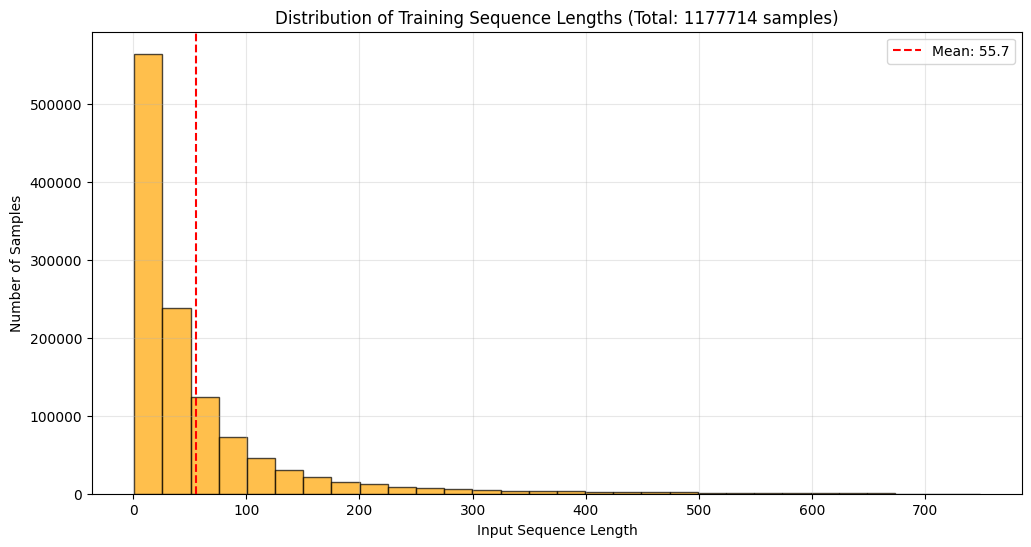

In [9]:

sequence_lengths = []
for quote in df['Quote'].astype(str):
    words = quote.split()
    for i in range(1, len(words)):
        sequence_lengths.append(i)

if sequence_lengths:
    plt.figure(figsize=(12, 6))
    plt.hist(sequence_lengths, bins=30, color='orange', edgecolor='black', alpha=0.7)
    plt.xlabel('Input Sequence Length')
    plt.ylabel('Number of Samples')
    plt.title(f'Distribution of Training Sequence Lengths (Total: {len(sequence_lengths)} samples)')
    plt.grid(True, alpha=0.3)
    plt.axvline(x=np.mean(sequence_lengths), color='red', linestyle='--',
                label=f'Mean: {np.mean(sequence_lengths):.1f}')
    plt.legend()
    plt.show()
else:
    print("No sequences generated (quotes might be empty)")

In [10]:

print(f"\n📈 Data Statistics:")
print(f"Total Quotes: {len(df)}")
print(f"Average Quote Length (chars): {np.mean(quote_lengths):.2f}")
print(f"Average Quote Length (words): {np.mean(quote_words):.2f}")
print(f"Total words in corpus: {len(all_text.split())}")
print(f"Unique words: {len(set(all_text.split()))}")
if sequence_lengths:
    print(f"Total training sequences: {len(sequence_lengths)}")
    print(f"Average sequence length: {np.mean(sequence_lengths):.2f}")
    print(f"Max sequence length: {max(sequence_lengths)}")
print("\n✅ All visualizations complete!")


📈 Data Statistics:
Total Quotes: 29355
Average Quote Length (chars): 226.58
Average Quote Length (words): 41.12
Total words in corpus: 1207069
Unique words: 96139
Total training sequences: 1177714
Average sequence length: 55.74
Max sequence length: 748

✅ All visualizations complete!
